[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CyrilPitrou/primat/blob/master/notebooks/AnimatedAbundances.ipynb)

# Animated BBN abundance evolution

Creates two animated GIFs of the small-network abundance evolution $A_i Y_i(t)$:

1. **`anim_deltaNeff.gif`** — sweeps $\Delta N_{\rm eff}$ from $-2$ to $+2$, keeping $\Omega_b h^2$ at its standard value.
2. **`anim_omegabh2.gif`** — sweeps $\Omega_b h^2$ from $0.005$ to $0.05$, keeping $\Delta N_{\rm eff} = 0$.

All runs use `network='small'` (8 nuclides, 12 reactions).  The data are precomputed
before the animation loop so that GIF rendering is fast.

In [1]:
import importlib.util, subprocess, sys

# In Colab (or any environment without a local primat checkout), pip-install
# the released package; local dev runs already have it importable (editable
# install / repo on sys.path via the cell below), so this is a no-op there.
if importlib.util.find_spec("primat") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "primat"], check=True)


In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.animation import FuncAnimation, PillowWriter

from primat.backend import run_bbn
from primat.evolution import Y_interpolator
from primat.config import PRIMATConfig

# Uses primat.backend.run_bbn() only (works on either backend); per-frame
# Y(t) interpolators come from primat.evolution.Y_interpolator on each run's
# EvolutionResult (output_time_evolution=True), the same backend-agnostic
# building block primat.plotting.abundance_evolution_curves() uses.
_A_SMALL = {name: NZ[0] + NZ[1] for name, NZ in PRIMATConfig({'network': 'small'}).Nuclides.items()}


In [3]:
# Time grid (1 s → 10^6 s) and species style shared by both animations.
# Each entry: (species key, line color, linestyle, legend label).
t = np.logspace(0, 6, 500)

SPECIES = [
    ('n',   'black',  'solid',   'n'),
    ('p',   'red',    'solid',   'p'),
    ('H2',  'red',    'dashed',  'D'),
    ('H3',  'red',    'dotted',  'T'),
    ('He3', 'blue',   'dashed',  r'$^3$He'),
    ('He4', 'blue',   'solid',   r'$^4$He'),
    ('Li7', 'green',  'dashed',  r'$^7$Li'),
    ('Be7', 'purple', 'solid',   r'$^7$Be'),
]

# Fixed axis limits that encompass all frames in both animations.
XLIM = (1, 1e6)
YLIM = (1e-12, 2)
FPS  = 5     # frames per second in the output GIF

os.makedirs('plots', exist_ok=True)

---
## Helper: precompute abundance tracks

Running PRIMAT inside a `FuncAnimation` update callback would be slow.
We instead precompute the masked $(t, A_i Y_i)$ arrays for every frame
and cache them in a list of dicts.

In [4]:
def precompute_runs(param_values, param_name, base_params=None):
    """
    Run the small-network BBN solve (via primat.backend.run_bbn) for each
    value in *param_values*, evaluating all species on *t*.

    Parameters
    ----------
    param_values : array-like
        Sequence of parameter values (one BBN solve per entry).
    param_name : str
        PRIMATConfig key to vary (e.g. ``'DeltaNeff'`` or ``'Omegabh2'``).
    base_params : dict, optional
        Fixed parameters shared by all runs (defaults to small network, silent).

    Returns
    -------
    frames : list of dict
        Each entry maps species name -> (t_masked, AY_masked) tuple.
    """
    base = {'network': 'small', 'verbose': False,
            'output_time_evolution': True, 'output_file': None}
    if base_params:
        base.update(base_params)

    frames = []
    n = len(param_values)
    for i, val in enumerate(param_values):
        print(f'\r  {param_name} = {val:.4g}  ({i+1}/{n})', end='', flush=True)
        result = run_bbn({**base, param_name: val})
        evolution = result['evolution']
        frame = {}
        for name, *_ in SPECIES:
            AY = _A_SMALL[name] * Y_interpolator(evolution, name)(t)
            mask = AY > 0
            frame[name] = (t[mask], AY[mask])
        frames.append(frame)
    print()  # newline after progress
    return frames


---
## Animation 1 — varying $\Delta N_{\rm eff}$

$\Delta N_{\rm eff}$ parametrises extra relativistic energy density beyond the
Standard Model value.  Increasing it raises the Hubble rate, shifting freeze-out
earlier and increasing $Y_P$; decreasing it has the opposite effect.

In [5]:
delta_neff_values = np.linspace(-2.0, 2.0, 21)  # 21 frames, step 0.2
print(f'Precomputing {len(delta_neff_values)} runs for ΔNeff sweep …')
frames_dneff = precompute_runs(delta_neff_values, 'DeltaNeff')

Precomputing 21 runs for ΔNeff sweep …
  DeltaNeff = -2  (1/21)

  DeltaNeff = -1.8  (2/21)

  DeltaNeff = -1.6  (3/21)

  DeltaNeff = -1.4  (4/21)

  DeltaNeff = -1.2  (5/21)

...

  DeltaNeff = 1.6  (19/21)

  done.
[primat]  HT.  MT.  LT.  done.
[primat]  HT.  MT.  LT.  done.
[primat]  HT.  MT.  LT.  done.
[primat]  HT.  MT.  LT.  done.
[primat]  HT.  MT.  LT.

  DeltaNeff = 1.8  (20/21)

  DeltaNeff = 2  (21/21)

  done.
[primat]  HT.  MT.  LT.  done.
[primat]  HT.  MT.  LT.  done.


In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Time [s]')
ax.set_ylabel(r'$A_i\,Y_i$')
ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)
ax.legend(
    handles=[
        plt.Line2D([0], [0], color=color, ls=ls, label=label)
        for _, color, ls, label in SPECIES
    ],
    ncol=2, loc='center left'
)

# One Line2D artist per species; updated each frame via set_data.
lines = {
    name: ax.plot([], [], color=color, ls=ls)[0]
    for name, color, ls, _ in SPECIES
}

# Parameter label in the upper-right corner.
param_text = ax.text(
    0.97, 0.77, '', transform=ax.transAxes,
    ha='right', va='bottom', fontsize=12, fontweight='bold',
    path_effects=[pe.withStroke(linewidth=3, foreground='white')]
)

def update_dneff(i):
    """Update all line artists and the annotation for frame *i*."""
    frame = frames_dneff[i]
    val   = delta_neff_values[i]
    ax.set_title(
        fr'BBN abundance evolution',
        fontsize=11
    )
    param_text.set_text(fr'$\Delta N_{{\rm eff}} = {val:+.2f}$')
    for name, *_ in SPECIES:
        t_m, AY_m = frame[name]
        lines[name].set_data(t_m, AY_m)
    return list(lines.values()) + [param_text]

anim_dneff = FuncAnimation(
    fig, update_dneff,
    frames=len(frames_dneff),
    interval=1000 // FPS,
    blit=False
)

out_dneff = 'plots/anim_deltaNeff.gif'
anim_dneff.save(out_dneff, writer=PillowWriter(fps=FPS))
plt.close(fig)
print(f'Saved → {out_dneff}')

Saved → plots/anim_deltaNeff.gif


Preview the $\Delta N_{\rm eff}$ animation:

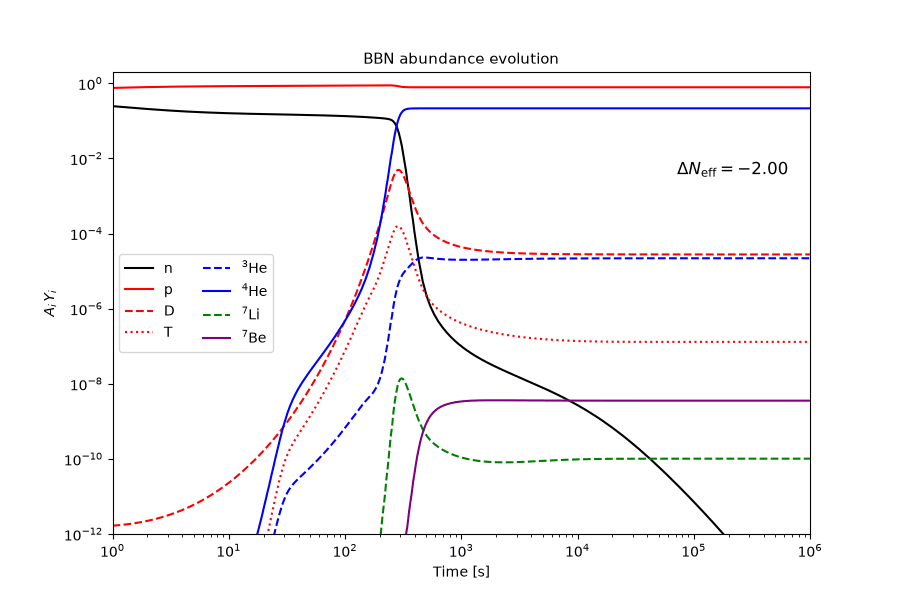

In [7]:
from IPython.display import Image
Image(out_dneff)

---
## Animation 2 — varying $\Omega_b h^2$

The baryon density $\Omega_b h^2$ controls the baryon-to-photon ratio $\eta_b$.
Higher $\Omega_b h^2$ accelerates nuclear burning, increasing $Y_P$ slightly,
reducing D/H (more efficient deuterium burning), and raising $^7$Li/$^7$Be.

In [8]:
omegabh2_values = np.linspace(0.005, 0.05, 19)  # 19 frames, step ~0.0025
print(f'Precomputing {len(omegabh2_values)} runs for Ωbh² sweep …')
frames_obh2 = precompute_runs(omegabh2_values, 'Omegabh2')

Precomputing 19 runs for Ωbh² sweep …
  Omegabh2 = 0.005  (1/19)

  Omegabh2 = 0.0075  (2/19)

  Omegabh2 = 0.01  (3/19)

  Omegabh2 = 0.0125  (4/19)

  Omegabh2 = 0.015  (5/19)

...

  Omegabh2 = 0.045  (17/19)

  Omegabh2 = 0.0475  (18/19)

  done.
[primat]  HT.  MT.  LT.  done.
[primat]  HT.  MT.  LT.  done.
[primat]  HT.  MT.  LT.  done.
[primat]  HT.  MT.  LT.  done.
[primat]  HT.  MT.  LT.  done.


  Omegabh2 = 0.05  (19/19)

[primat]  HT.  MT.  LT.  done.
[primat]  HT.  MT.  LT.  done.


In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Time [s]')
ax.set_ylabel(r'$A_i\,Y_i$')
ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)
ax.legend(
    handles=[
        plt.Line2D([0], [0], color=color, ls=ls, label=label)
        for _, color, ls, label in SPECIES
    ],
    ncol=2, loc='center left'
)

lines = {
    name: ax.plot([], [], color=color, ls=ls)[0]
    for name, color, ls, _ in SPECIES
}

param_text = ax.text(
    0.97, 0.7, '', transform=ax.transAxes,
    ha='right', va='bottom', fontsize=12, fontweight='bold',
    path_effects=[pe.withStroke(linewidth=3, foreground='white')]
)

def update_obh2(i):
    """Update all line artists and the annotation for frame *i*."""
    frame = frames_obh2[i]
    val   = omegabh2_values[i]
    ax.set_title(
        fr'BBN abundance evolution',
        fontsize=11
    )
    param_text.set_text(fr'$\Omega_b h^2 = {val:.4f}$')
    for name, *_ in SPECIES:
        t_m, AY_m = frame[name]
        lines[name].set_data(t_m, AY_m)
    return list(lines.values()) + [param_text]

anim_obh2 = FuncAnimation(
    fig, update_obh2,
    frames=len(frames_obh2),
    interval=1000 // FPS,
    blit=False
)

out_obh2 = 'plots/anim_omegabh2.gif'
anim_obh2.save(out_obh2, writer=PillowWriter(fps=FPS))
plt.close(fig)
print(f'Saved → {out_obh2}')

Saved → plots/anim_omegabh2.gif


Preview the $\Omega_b h^2$ animation:

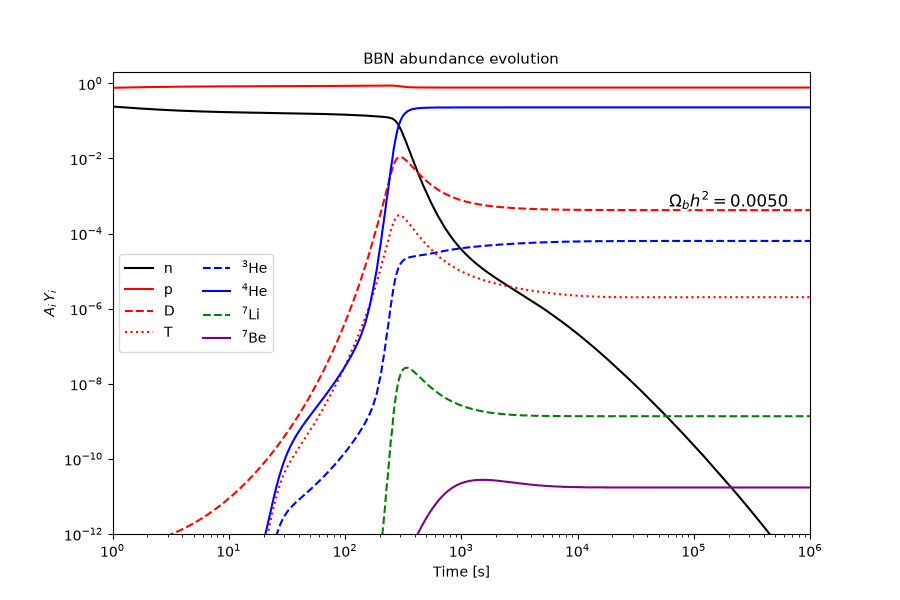

In [10]:
from IPython.display import Image
Image(out_obh2)